In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from mpl_toolkits.mplot3d import Axes3D
import glob
import os
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

# Analisis de todos los datos juntos (Sibyl-Helio-17.5-18eV) - Prueba para Generador de Reportes

In [2]:
# --- 1. Cargar el "Mega-DataFrame" ---
parquet_dir = "/home/lsilva/Github/ADST_Alexey_module_v4/parquet_sib_helio_17/"
all_parquet_files = glob.glob(os.path.join(parquet_dir, "*.parquet"))
all_parquet_files.sort()

print(f"Encontrados {len(all_parquet_files)} archivos .parquet.")

df_list = []
for fpath in all_parquet_files:
    df_list.append(pd.read_parquet(fpath))

df_new = pd.concat(df_list, ignore_index=True)

# --- 2. Limpieza y Reporte ---
    
# 1. Guardamos la cantidad inicial
n_rows_inicial = len(df_new)
    
# 2. Reemplazar infinitos por NaN
df_new.replace([np.inf, -np.inf], np.nan, inplace=True)
    
# 3. (Opcional pero útil) Ver dónde están los problemas antes de borrar
# Esto te dice qué columna es la que más falla
nans_count = df_new[['logE_REC', 'theta_REC', 'phi_REC']].isna().sum()
    
# 4. Ejecutar el drop
df_new.dropna(subset=['logE_REC', 'theta_REC', 'phi_REC'], inplace=True)
    
# 5. Calcular la diferencia
n_rows_final = len(df_new)
n_dropped = n_rows_inicial - n_rows_final
percent_dropped = (n_dropped / n_rows_inicial) * 100 if n_rows_inicial > 0 else 0

# --- IMPRIMIR REPORTE ---
print("\n" + "="*40)
print("REPORTE DE LIMPIEZA DE DATOS")
print("="*40)
print(f"Filas Iniciales:     {n_rows_inicial:10d}")
print(f"Filas Eliminadas:    {n_dropped:10d} ({percent_dropped:.2f}%)")
print(f"Filas Finales:       {n_rows_final:10d}")
print("-" * 40)
if n_dropped > 0:
    print("Causas (NaNs por columna):")
    print(nans_count[nans_count > 0].to_string())
print("="*40 + "\n")

print(f"DataFrame 'df_new' (módulos) cargado y limpio.")
print(df_new.head())
print(df_new.columns)

# --- 3. Crear el DataFrame de EVENTOS ---
event_cols = [
    "run_number", "event_id",
    "logE_MC", "theta_MC", "phi_MC", "primary",
    "logE_REC", "theta_REC", "phi_REC"
]
df_events = df_new[event_cols].drop_duplicates()

print(f"DataFrame 'df_events' (lluvias) creado con {len(df_events)} filas únicas.")

Encontrados 20 archivos .parquet.

REPORTE DE LIMPIEZA DE DATOS
Filas Iniciales:        1623057
Filas Eliminadas:         59040 (3.64%)
Filas Finales:          1564017
----------------------------------------
Causas (NaNs por columna):
logE_REC    59040

DataFrame 'df_new' (módulos) cargado y limpio.
                                            event_id    logE_MC   theta_MC  \
0  Library_Prague_Santos_Yushkov:Run_10000:Shower...  17.557002  10.497525   
1  Library_Prague_Santos_Yushkov:Run_10000:Shower...  17.557002  10.497525   
2  Library_Prague_Santos_Yushkov:Run_10000:Shower...  17.557002  10.497525   
3  Library_Prague_Santos_Yushkov:Run_10000:Shower...  17.557002  10.497525   
4  Library_Prague_Santos_Yushkov:Run_10000:Shower...  17.557002  10.497525   

       phi_MC primary   logE_REC  theta_REC     phi_REC  counterId  moduleId  \
0  266.129022      He  17.424415   9.516247  269.459517      90000         1   
1  266.129022      He  17.424415   9.516247  269.459517      90000   

In [16]:
print(df_new["event_id"][2000])

Library_Prague_Santos_Yushkov:Run_10030:Shower_1:Use_1


Generando gráfico 3D...


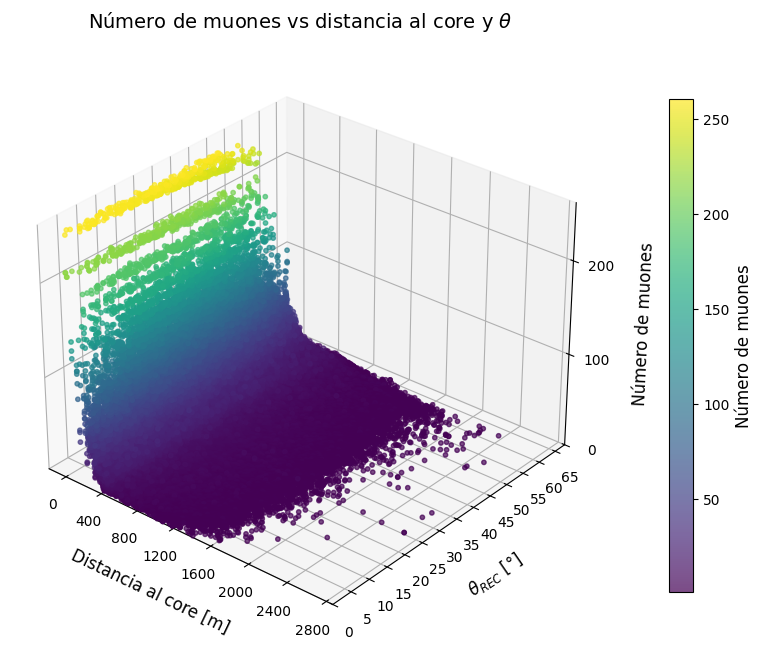

In [3]:
print("Generando gráfico 3D...")

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# (Opcional) Filtremos un poco para que el plot sea más claro
# ej: sacamos counters sin muones o muy lejanos
df_plot = df_new[
    (df_new['nMuones_REC'] > 0) &
    (df_new['r_core'] < 2800) # (Ajustá este límite si es necesario)
]

# Scatter
sc = ax.scatter(
    df_plot["r_core"],
    df_plot["theta_REC"],  # <-- Columna renombrada
    df_plot["nMuones_REC"],
    c=df_plot["nMuones_REC"], 
    cmap="viridis", 
    alpha=0.7,
    s=10 # Hago los puntos un poco más chicos
)

# Labels
ax.set_xlabel("Distancia al core [m]", fontsize=12, labelpad=10)
ax.set_ylabel(r"$\theta_{REC}$ [°]", fontsize=12, labelpad=10) # <-- Label actualizado
ax.set_zlabel("Número de muones", fontsize=12, labelpad=10)
plt.title(r"Número de muones vs distancia al core y $\theta$", fontsize=14, pad=20)

# Mejorar ticks (usando tu configuración)
ax.set_xticks(np.arange(0, 2800 + 1, 400))
ax.set_yticks(np.arange(0, 66 + 1, 5))
ax.set_ylim(0, 68) # (Tal vez quieras subir este límite si tus datos llegan a 60°)

# Zticks: Usar un log-scale o binear puede ser mejor
# pero siguiendo tu código original:
z_max = df_plot["nMuones_REC"].max()
ax.set_zticks(np.arange(0, z_max + 1, 100)) # Ajustado a 100, ya que 50 era muy denso
ax.set_zlim(0, z_max) # Asegurarse de que el eje Z llegue al máximo

# Añadir barra de color
cbar = plt.colorbar(sc, pad=0.1, shrink=0.8)
cbar.set_label("Número de muones", fontsize=12)

# Rotar la vista
ax.view_init(elev=30, azim=310)

# Grid
ax.grid(True)

plt.show()

--- Análisis de Resolución: Energía ---


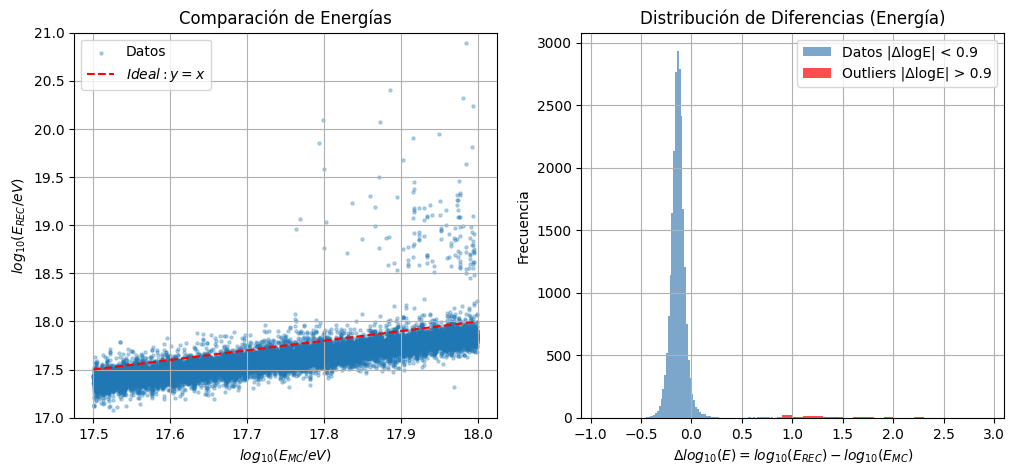

  Sesgo (Promedio ΔlogE total): -0.1270
  Resolución (Std ΔlogE total): 0.1179
  Eventos con |ΔE| > 0.9: 75 (de 23332 eventos, 0.32%)

--- Análisis de Residuales: ΔlogE vs logE_MC ---


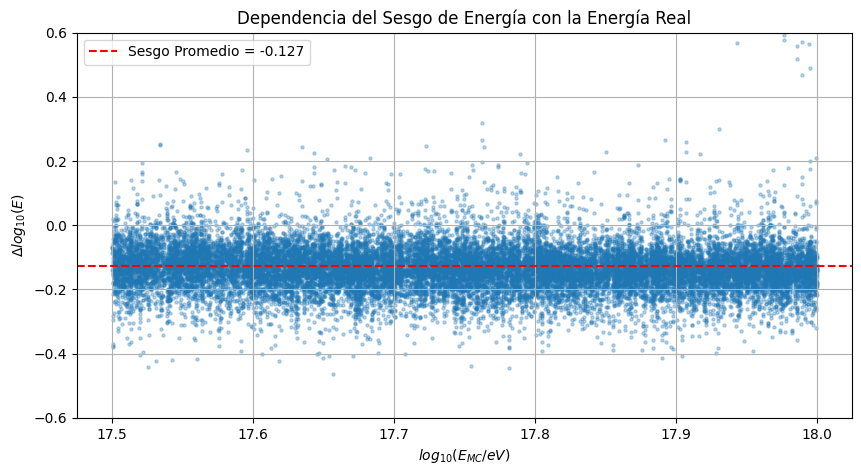



--- Análisis de Resolución: Ángulo Cenital (Theta) ---


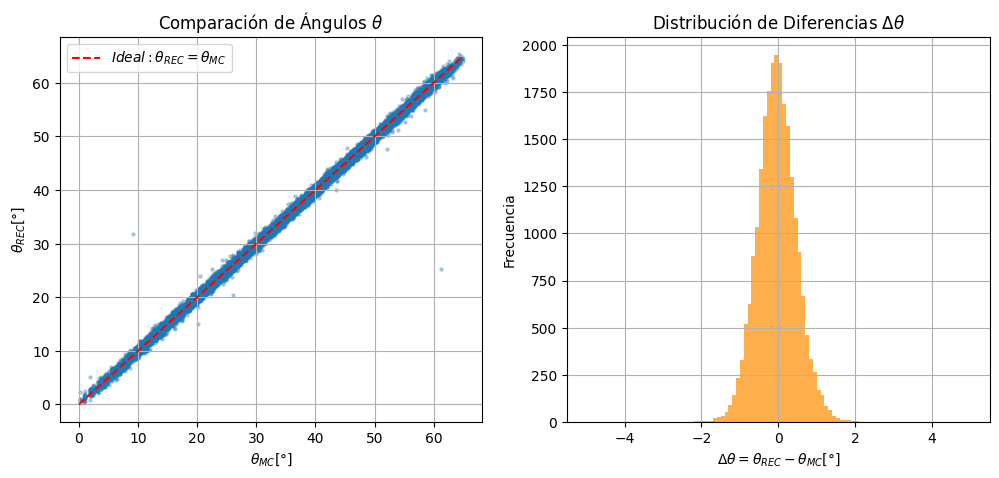

  Sesgo (Promedio Δθ): -0.0413°
  Resolución (Std Dev Δθ): 0.5828°
  Eventos con |Δθ| > 10.0°: 2 (de 23332 eventos, 0.01%)


--- Análisis de Resolución: Ángulo Azimutal (Phi) ---


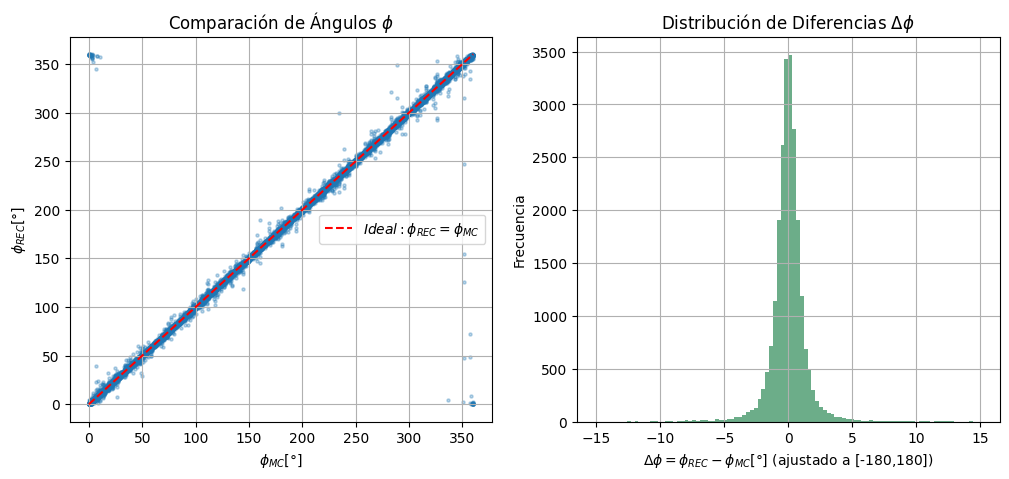

  Sesgo (Mediana Δφ): 0.0105°
  Resolución (MAD Δφ): 0.5599°
  Eventos con |Δφ| > 15.0°: 43 (de 23332 eventos, 0.18%)




In [4]:
# --- 1. Análisis de ENERGÍA (con Ajuste Lineal Robusto) ---
print("--- Análisis de Resolución: Energía ---")

X_full = df_events["logE_MC"]
Y_full = df_events["logE_REC"]
deltaE_full = Y_full - X_full

# --- ❗️ 1. TU FILTRO DE OUTLIERS ❗️ ---
# Definimos el umbral y filtramos el DataFrame SÓLO para el ajuste
umbral_E = 0.9 # Un |ΔlogE| > 0.9 es un outlier
df_fit = df_events[(deltaE_full.abs() < umbral_E)]
cant_outliers = len(df_events)-len(df_fit)


plt.figure(figsize=(12, 5))

# Scatter plot
plt.subplot(1, 2, 1)
# Ploteamos TODOS los puntos (para ver los outliers)
plt.scatter(X_full, Y_full, s=5, alpha=0.3, label='Datos')
plt.plot([17.5, 18.0], [17.5, 18.0], 'r--', label=r"$Ideal: y=x$")
plt.xlabel(r"$log_{10}(E_{MC} / eV)$")
plt.ylabel(r"$log_{10}(E_{REC} / eV)$")
plt.title("Comparación de Energías")
plt.legend()
plt.grid(True)
plt.ylim(17.0, 21.0) # Ajustamos el Y-lim para ver los outliers

# Histograma de diferencias (de TODOS los datos)
plt.subplot(1, 2, 2)
plt.hist(deltaE_full, bins=100, range=(-0.9, 0.9), alpha=0.7, color='steelblue', label='Datos |ΔlogE| < 0.9')
# Histograma de los outliers
plt.hist(deltaE_full[deltaE_full.abs() >= 0.9], bins=20, alpha=0.7, color='red', label='Outliers |ΔlogE| > 0.9')
plt.xlabel(r"$\Delta log_{10}(E) = log_{10}(E_{REC}) - log_{10}(E_{MC})$")
plt.ylabel("Frecuencia")
plt.title("Distribución de Diferencias (Energía)")
plt.legend()
plt.grid(True)
plt.show()

# Métricas de Energía (sobre el total de datos, como antes)
print(f"  Sesgo (Promedio ΔlogE total): {deltaE_full.mean():.4f}")
print(f"  Resolución (Std ΔlogE total): {deltaE_full.std():.4f}")
print(f"  Eventos con |ΔE| > {umbral_E}: {cant_outliers} (de {len(df_events)} eventos, {cant_outliers*100/len(df_events):.2f}%)\n")


# --- ❗️ 3. TU NUEVO PLOT (Residuales vs Energía) ❗️ ---
# Plot de ΔlogE vs logE_MC
print("--- Análisis de Residuales: ΔlogE vs logE_MC ---")
plt.figure(figsize=(10, 5))
plt.scatter(X_full, deltaE_full, s=5, alpha=0.3)
# Línea de sesgo promedio
plt.axhline(deltaE_full.mean(), color='r', linestyle='--', 
            label=f'Sesgo Promedio = {deltaE_full.mean():.3f}')
plt.xlabel(r"$log_{10}(E_{MC} / eV)$")
plt.ylabel(r"$\Delta log_{10}(E)$")
plt.title("Dependencia del Sesgo de Energía con la Energía Real")
plt.legend()
plt.grid(True)
plt.ylim(-0.6, 0.6) # Filtramos outliers visualmente
plt.show()
print("\n")


# --- 4. Análisis de THETA (con umbral de 10°) ---
print("--- Análisis de Resolución: Ángulo Cenital (Theta) ---")
plt.figure(figsize=(12, 5))

# Scatter plot
plt.subplot(1, 2, 1)
plt.scatter(df_events["theta_MC"], df_events["theta_REC"], s=5, alpha=0.3)
plt.plot([0, 65], [0, 65], 'r--', label=r"$Ideal: \theta_{REC} = \theta_{MC}$")
plt.xlabel(r"$\theta_{MC} [°]$")
plt.ylabel(r"$\theta_{REC} [°]$")
plt.title(r"Comparación de Ángulos $\theta$")
plt.legend()
plt.grid(True)

# Histograma de diferencias
plt.subplot(1, 2, 2)
delta_theta = df_events["theta_REC"] - df_events["theta_MC"]
plt.hist(delta_theta, bins=100, range=(-5, 5), alpha=0.7, color='darkorange') # Rango ampliado
plt.xlabel(r"$\Delta \theta = \theta_{REC} - \theta_{MC} [°]$")
plt.ylabel("Frecuencia")
plt.title(r"Distribución de Diferencias $\Delta \theta$")
plt.grid(True)
plt.show()

# Métricas de Theta (con tu nuevo umbral)
print(f"  Sesgo (Promedio Δθ): {delta_theta.mean():.4f}°")
print(f"  Resolución (Std Dev Δθ): {delta_theta.std():.4f}°")
# ❗️ UMBRAL CORREGIDO
umbral_theta = 10.0
mal_theta = delta_theta.abs() > umbral_theta
print(f"  Eventos con |Δθ| > {umbral_theta}°: {mal_theta.sum()} (de {len(df_events)} eventos, {mal_theta.mean()*100:.2f}%)")
print("\n")


# --- 5. Análisis de PHI (con umbral de 15° y fix de .mad()) ---
print("--- Análisis de Resolución: Ángulo Azimutal (Phi) ---")
plt.figure(figsize=(12, 5))

# Scatter plot
plt.subplot(1, 2, 1)
plt.scatter(df_events["phi_MC"], df_events["phi_REC"], s=5, alpha=0.3)
plt.plot([0, 360], [0, 360], 'r--', label=r"$Ideal: \phi_{REC} = \phi_{MC}$")
plt.xlabel(r"$\phi_{MC} [°]$")
plt.ylabel(r"$\phi_{REC} [°]$")
plt.title(r"Comparación de Ángulos $\phi$")
plt.legend()
plt.grid(True)

# Histograma de diferencias
plt.subplot(1, 2, 2)
delta_phi = (df_events["phi_REC"] - df_events["phi_MC"] + 180) % 360 - 180
plt.hist(delta_phi, bins=100, range=(-15, 15), alpha=0.7, color='seagreen')
plt.xlabel(r"$\Delta \phi = \phi_{REC} - \phi_{MC} [°]$ (ajustado a [-180,180])")
plt.ylabel("Frecuencia")
plt.title(r"Distribución de Diferencias $\Delta \phi$")
plt.grid(True)
plt.show()

# --- ❗️ CORRECCIÓN DE .mad() ---
# 'mad()' no existe, usamos la definición: mediana(abs(x - mediana(x)))
median_phi = delta_phi.median()
mad_phi = (delta_phi - median_phi).abs().median()
# --- FIN DE LA CORRECCIÓN ---

# Métricas de Phi
print(f"  Sesgo (Mediana Δφ): {median_phi:.4f}°")
print(f"  Resolución (MAD Δφ): {mad_phi:.4f}°")
# ❗️ UMBRAL CORREGIDO
umbral_phi = 15.0
mal_phi = delta_phi.abs() > umbral_phi
print(f"  Eventos con |Δφ| > {umbral_phi}°: {mal_phi.sum()} (de {len(df_events)} eventos, {mal_phi.mean()*100:.2f}%)")
print("\n")

Total counters con señal: 114
Counters Anillo Denso: 12


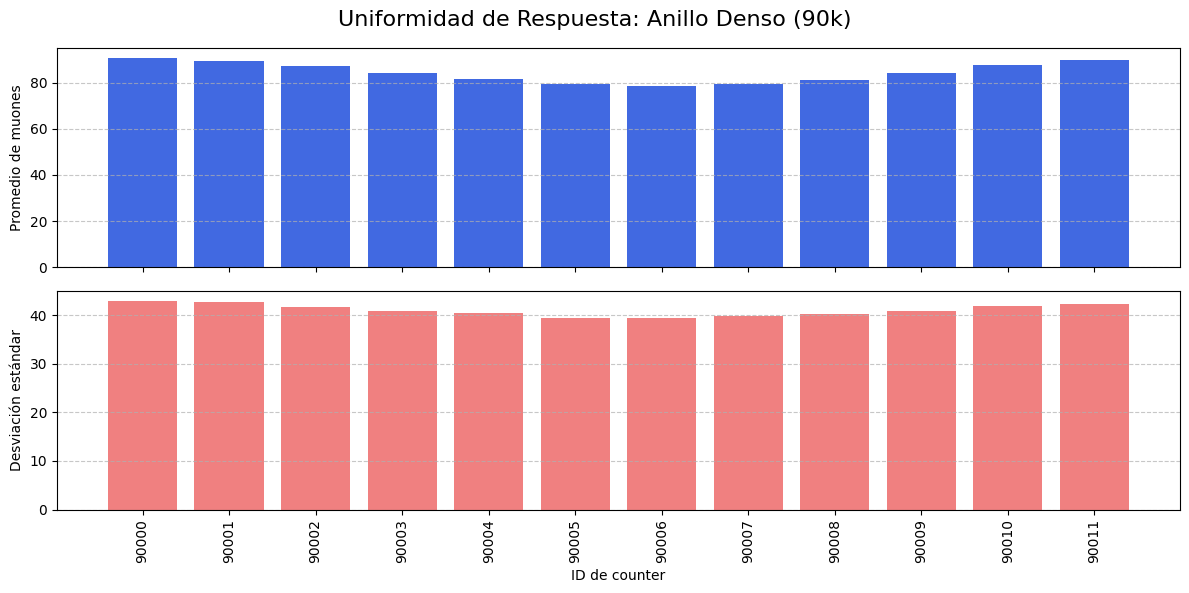

Counters Infill: 102


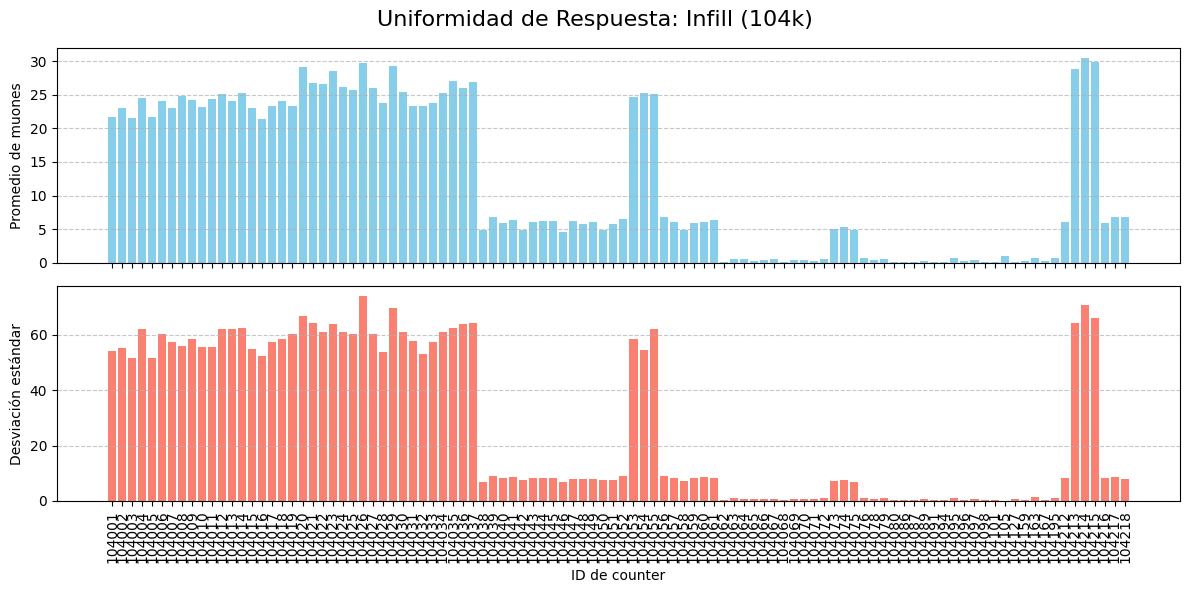

In [5]:
# --- Uniformidad por COUNTER (Dividido: Anillo Denso vs Infill) ---

# 1. Agrupamos por evento Y counter, y sumamos los nMuones de los módulos
df_counters = df_new.groupby(['event_id', 'counterId'])['nMuones_REC'].sum().reset_index()

# 2. Calculamos los estadísticos
counter_stats = df_counters.groupby('counterId')['nMuones_REC'].agg(
    promedio='mean', 
    std_dev='std',
    cantidad='count'
).reset_index()

# 3. Filtramos los counters con señal > 0
stats_con_senal = counter_stats[counter_stats['promedio'] > 0].copy()
stats_con_senal['counterId_str'] = stats_con_senal['counterId'].astype(str)

print(f"Total counters con señal: {len(stats_con_senal)}")

# --- 4. DIVIDIMOS EN DOS GRUPOS ---
df_dense = stats_con_senal[stats_con_senal['counterId'] < 100000].copy()
df_infill = stats_con_senal[stats_con_senal['counterId'] >= 100000].copy()

# --- Función auxiliar para plotear ---
def plot_uniformity(df, title_suffix, color_mean, color_std):
    if df.empty:
        print(f"No hay datos para {title_suffix}")
        return
        
    fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    fig.suptitle(f"Uniformidad de Respuesta: {title_suffix}", fontsize=16)

    # Promedio
    axs[0].bar(df['counterId_str'], df['promedio'], color=color_mean)
    axs[0].set_ylabel("Promedio de muones")
    axs[0].grid(axis='y', linestyle='--', alpha=0.7)

    # Desviación estándar
    axs[1].bar(df['counterId_str'], df['std_dev'], color=color_std)
    axs[1].set_ylabel("Desviación estándar")
    axs[1].set_xlabel("ID de counter")
    axs[1].grid(axis='y', linestyle='--', alpha=0.7)

    # Rotar etiquetas del eje X para que se lean bien
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

# --- 5. Generar los Plots ---

# Plot 1: Anillo Denso (90k)
print(f"Counters Anillo Denso: {len(df_dense)}")
plot_uniformity(df_dense, "Anillo Denso (90k)", "royalblue", "lightcoral")

# Plot 2: Infill (104k)
print(f"Counters Infill: {len(df_infill)}")
# Para el infill, como son muchos, quizás quieras mostrar menos etiquetas en el eje X
# Si no, usá la función tal cual:
plot_uniformity(df_infill, "Infill (104k)", "skyblue", "salmon")

Bordes de bins en Theta (grados): [ 0.  21.8 31.6 40.  47.9 56.  65.3]

Analizando asimetría por Counter ID (REC vs MC)...
  Bin 0: 157032 módulos.


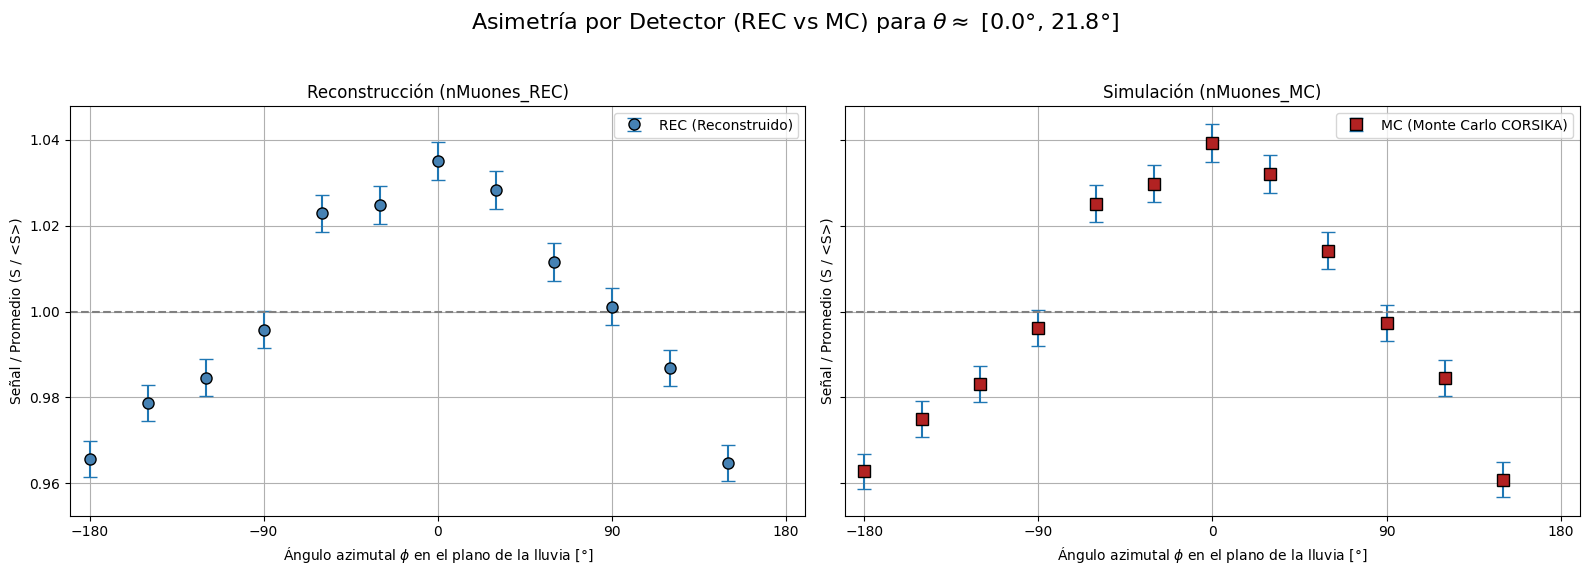

  Bin 1: 149541 módulos.


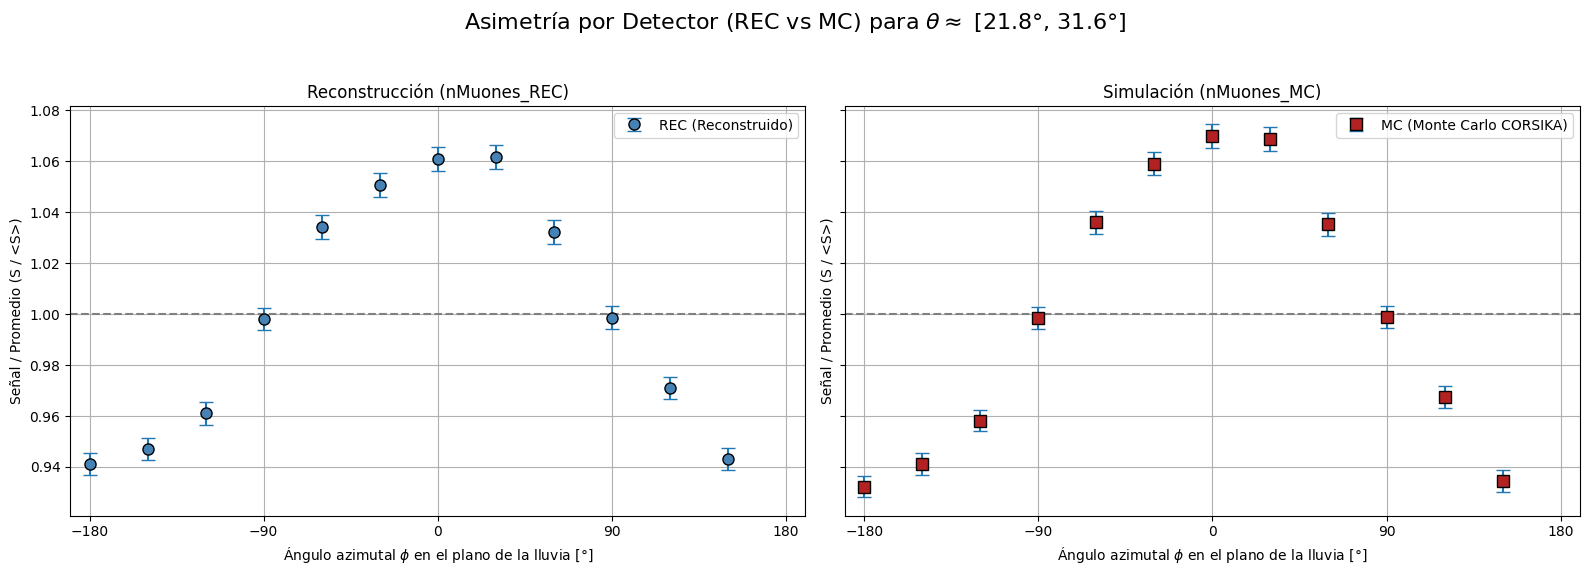

  Bin 2: 147888 módulos.


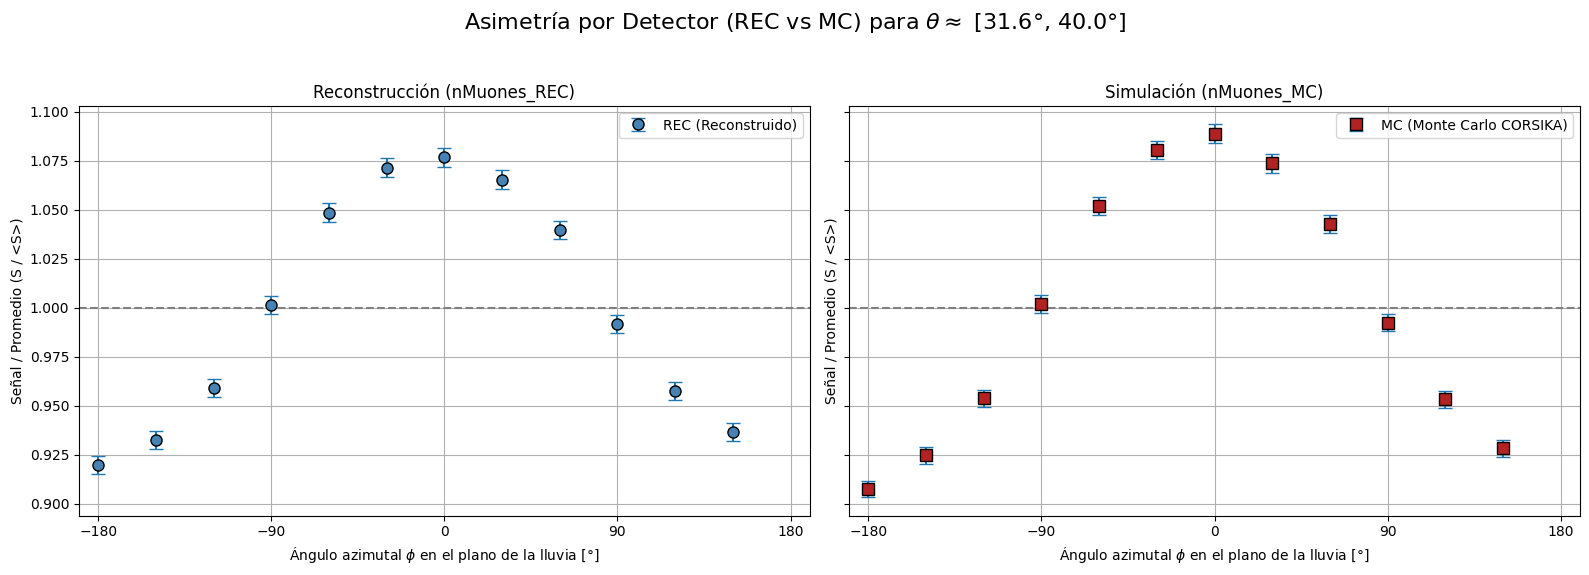

  Bin 3: 147768 módulos.


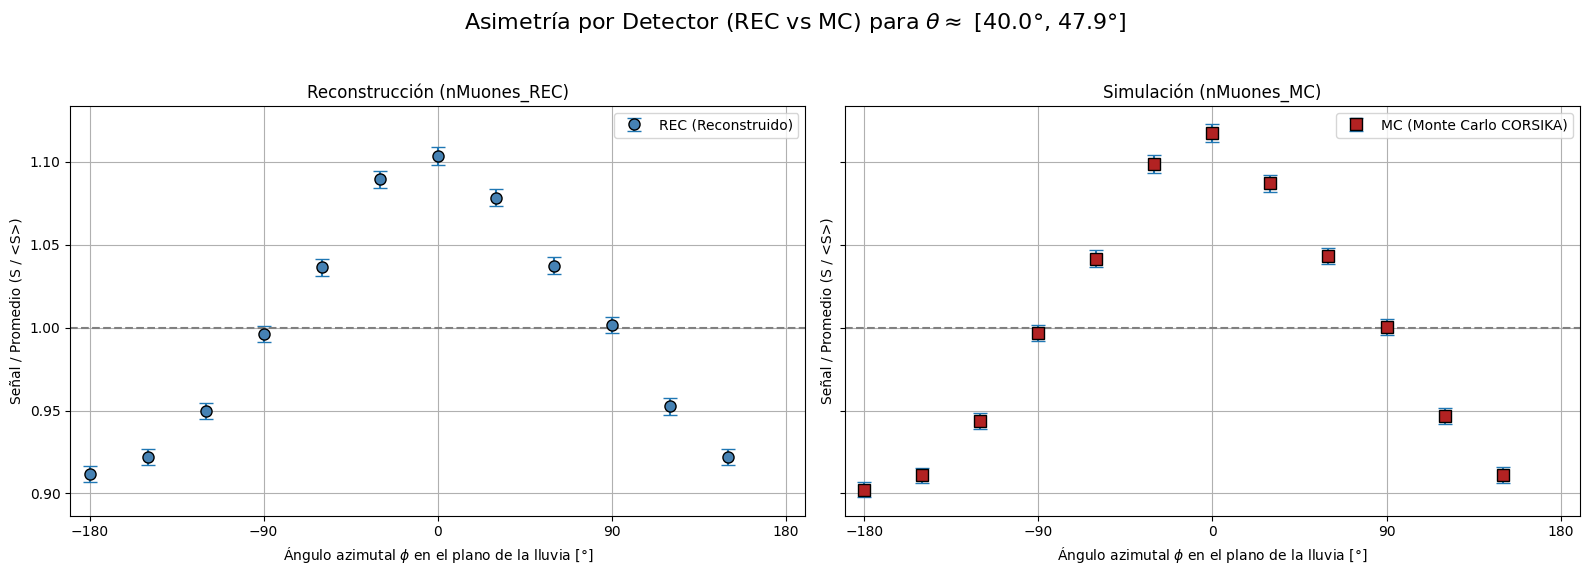

  Bin 4: 143457 módulos.


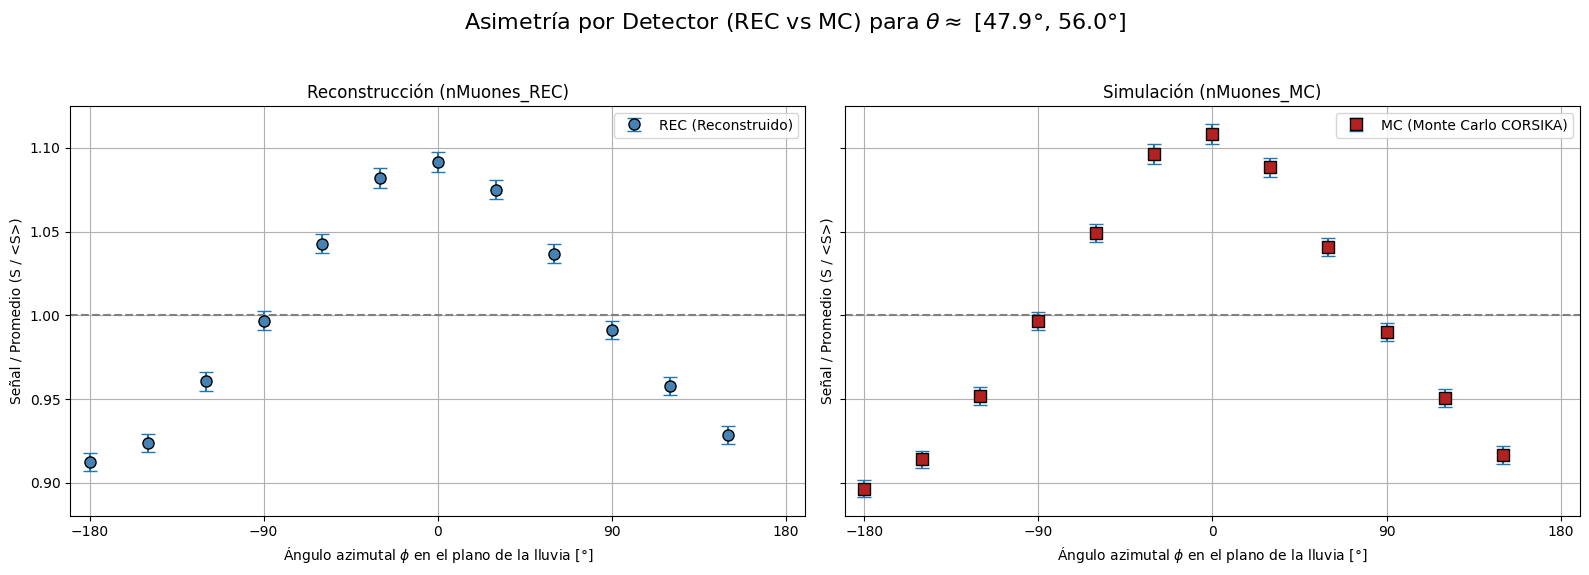

  Bin 5: 87480 módulos.


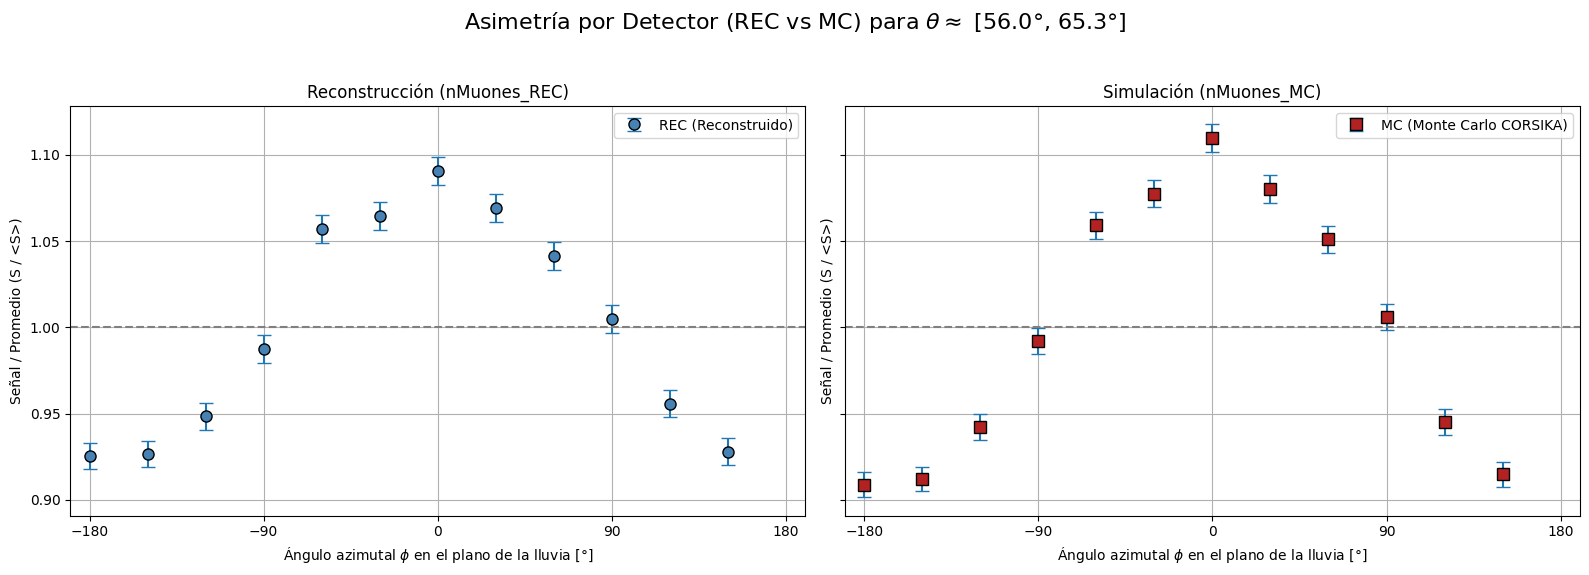

In [6]:
# --- 1. Configuración de los Detectores del Anillo Denso ---

# Mapeamos el ID al ángulo teórico (en grados, de -180 a 180)
dense_ring_ids = np.arange(90000, 90012)

# Ángulos teóricos (0, 30, 60, ..., 330)
angles_deg = np.linspace(0, 330, 12)

# Centramos en 0 (-180 a 180)
angles_centered = (angles_deg + 180) % 360 - 180

# Creamos un diccionario para mapear ID -> Ángulo
id_to_angle = dict(zip(dense_ring_ids, angles_centered))

# --- 2. Binning en Theta ---
N_theta_bins = 6
theta_min_deg = 0
theta_max_deg = 66
theta_max_real = df_new['theta_REC'].max()
theta_max_deg = min(theta_max_deg, theta_max_real) 
s2_min = np.sin(np.deg2rad(theta_min_deg))**2
s2_max = np.sin(np.deg2rad(theta_max_deg))**2
s2_bins = np.linspace(s2_min, s2_max, N_theta_bins + 1)
theta_bins_deg = np.rad2deg(np.arcsin(np.sqrt(s2_bins)))

print(f"Bordes de bins en Theta (grados): {np.round(theta_bins_deg, 1)}")

if 's2_theta' not in df_new.columns:
    df_new['s2_theta'] = np.sin(np.deg2rad(df_new['theta_REC']))**2
    df_new['theta_bin'] = pd.cut(df_new['s2_theta'], bins=s2_bins, labels=False, include_lowest=True)

# --- 3. FILTRAMOS Y LIMPIAMOS ---
status_buenos = ['candidate', 'rejected', 'saturated']
df_limpio = df_new[
    (df_new['module_status'].isin(status_buenos))
].copy()

# Solo Anillo Denso
df_anillo_denso = df_limpio[
    (df_limpio['counterId'] >= 90000) & 
    (df_limpio['counterId'] < 100000)
].copy()

# Asignamos el ángulo teórico a cada fila según su ID
df_anillo_denso['phi'] = df_anillo_denso['counterId'].map(id_to_angle)

print(f"\nAnalizando asimetría por Counter ID (REC vs MC)...")

# --- 4. Bucle anidado ---
for i in range(N_theta_bins):
    
    th_min_label = theta_bins_deg[i]
    th_max_label = theta_bins_deg[i+1]
    plot_title = f"Asimetría por Detector (REC vs MC) para $\\theta \\approx$ [{th_min_label:.1f}°, {th_max_label:.1f}°]"

    df_slice = df_anillo_denso[
        (df_anillo_denso['theta_bin'] == i) &
        (df_anillo_denso['nMuones_REC'].notna()) &
        (df_anillo_denso['nMuones_MC'].notna()) # Aseguramos que ambos existan
    ].copy()

    if df_slice.empty or len(df_slice) < 50:
        print(f"  Bin {i}: Datos insuficientes.")
        continue
    
    print(f"  Bin {i}: {len(df_slice)} módulos.")

    # --- CÁLCULO DE DENSIDAD POR COUNTER ID ---
    # Agrupamos directamente por el ángulo teórico (que es equivalente al ID)
    stats = df_slice.groupby('phi').agg(
        rec_mean=('nMuones_REC', 'mean'),
        rec_std=('nMuones_REC', 'std'),
        rec_count=('nMuones_REC', 'count'),
        
        mc_mean=('nMuones_MC', 'mean'),
        mc_std=('nMuones_MC', 'std'),
        mc_count=('nMuones_MC', 'count')
    ).reset_index()
    
    # SEM (Error Estándar)
    stats['rec_sem'] = stats['rec_std'] / np.sqrt(stats['rec_count'])
    stats['mc_sem'] = stats['mc_std'] / np.sqrt(stats['mc_count'])
    
    # Normalización (S/<S>)
    rec_global_mean = stats['rec_mean'].mean()
    mc_global_mean = stats['mc_mean'].mean()
    
    stats['rec_norm'] = stats['rec_mean'] / rec_global_mean
    stats['rec_norm_err'] = stats['rec_sem'] / rec_global_mean
    
    stats['mc_norm'] = stats['mc_mean'] / mc_global_mean
    stats['mc_norm_err'] = stats['mc_sem'] / mc_global_mean

    # --- PLOT SIDE-BY-SIDE ---
    fig, axs = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
    fig.suptitle(plot_title, fontsize=16)
    
    # Plot REC
    axs[0].errorbar(
        stats['phi'], stats['rec_norm'], yerr=stats['rec_norm_err'],
        fmt='o', ms=8, mec='black', mfc='steelblue', capsize=5, label='REC (Reconstruido)'
    )
    axs[0].set_title(f"Reconstrucción (nMuones_REC)")
    
    # Plot MC
    axs[1].errorbar(
        stats['phi'], stats['mc_norm'], yerr=stats['mc_norm_err'],
        fmt='s', ms=8, mec='black', mfc='firebrick', capsize=5, label='MC (Monte Carlo CORSIKA)'
    )
    axs[1].set_title(f"Simulación (nMuones_MC)")
    
    # Styling común
    for ax in axs:
        ax.set_xlabel(r"Ángulo azimutal $\phi$ en el plano de la lluvia [°]")
        ax.set_ylabel(r"Señal / Promedio (S / <S>)")
        ax.set_xticks(np.arange(-180, 181, 90))
        ax.set_xlim(-190, 190)
        ax.axhline(1.0, color='gray', linestyle='--')
        ax.grid(True)
        ax.legend()
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

Bordes de bins en Theta (grados): [ 0.  21.7 31.6 39.9 47.7 55.8 65. ]
Usando 833166 filas (módulos) 'limpios' del Anillo Denso

Analizando asimetría en el Anillo Denso (IDs 90k)...
  Procesando bin de theta 0 ([0.0°, 21.7°]): 157032 módulos encontrados.


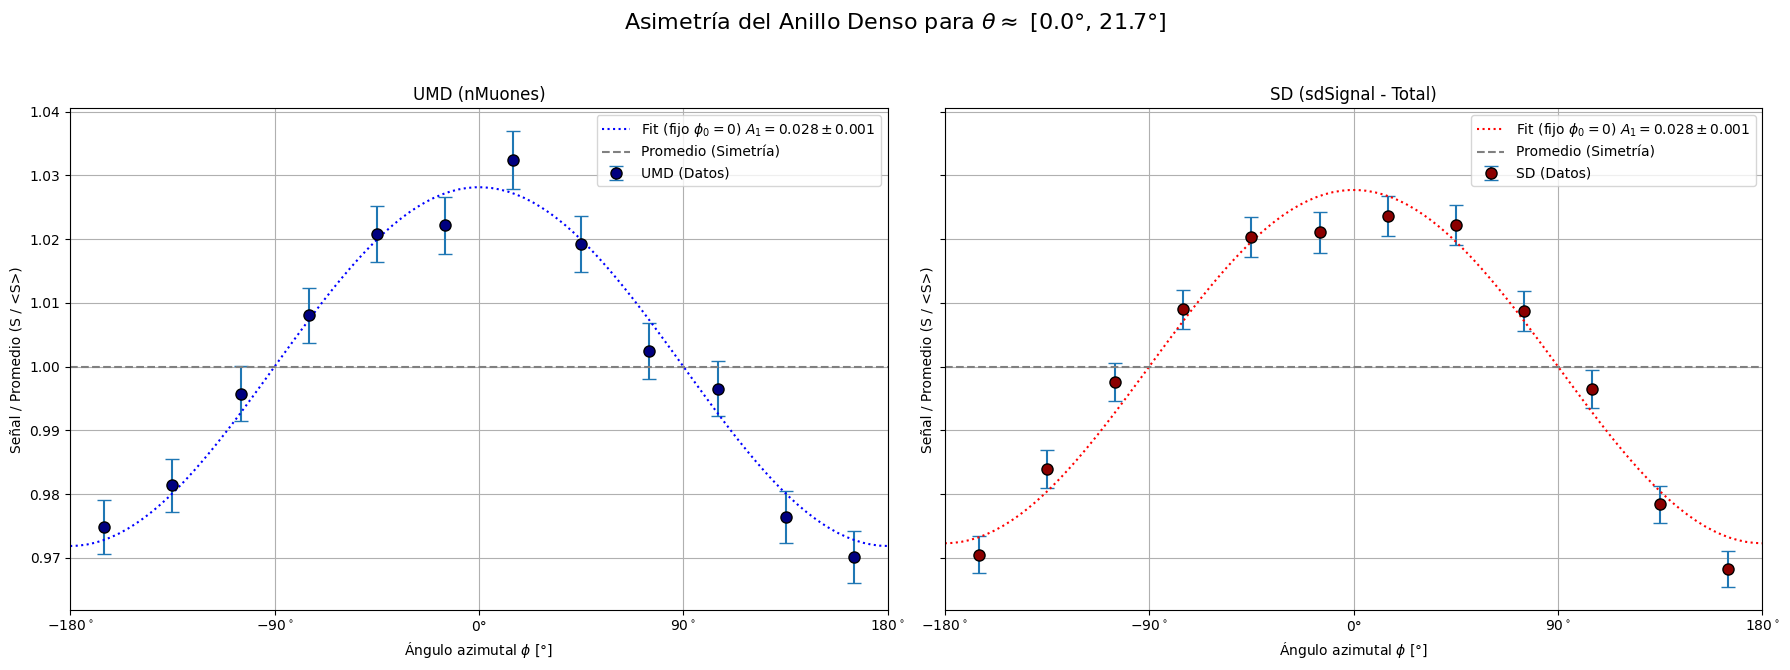

  Procesando bin de theta 1 ([21.7°, 31.6°]): 149541 módulos encontrados.


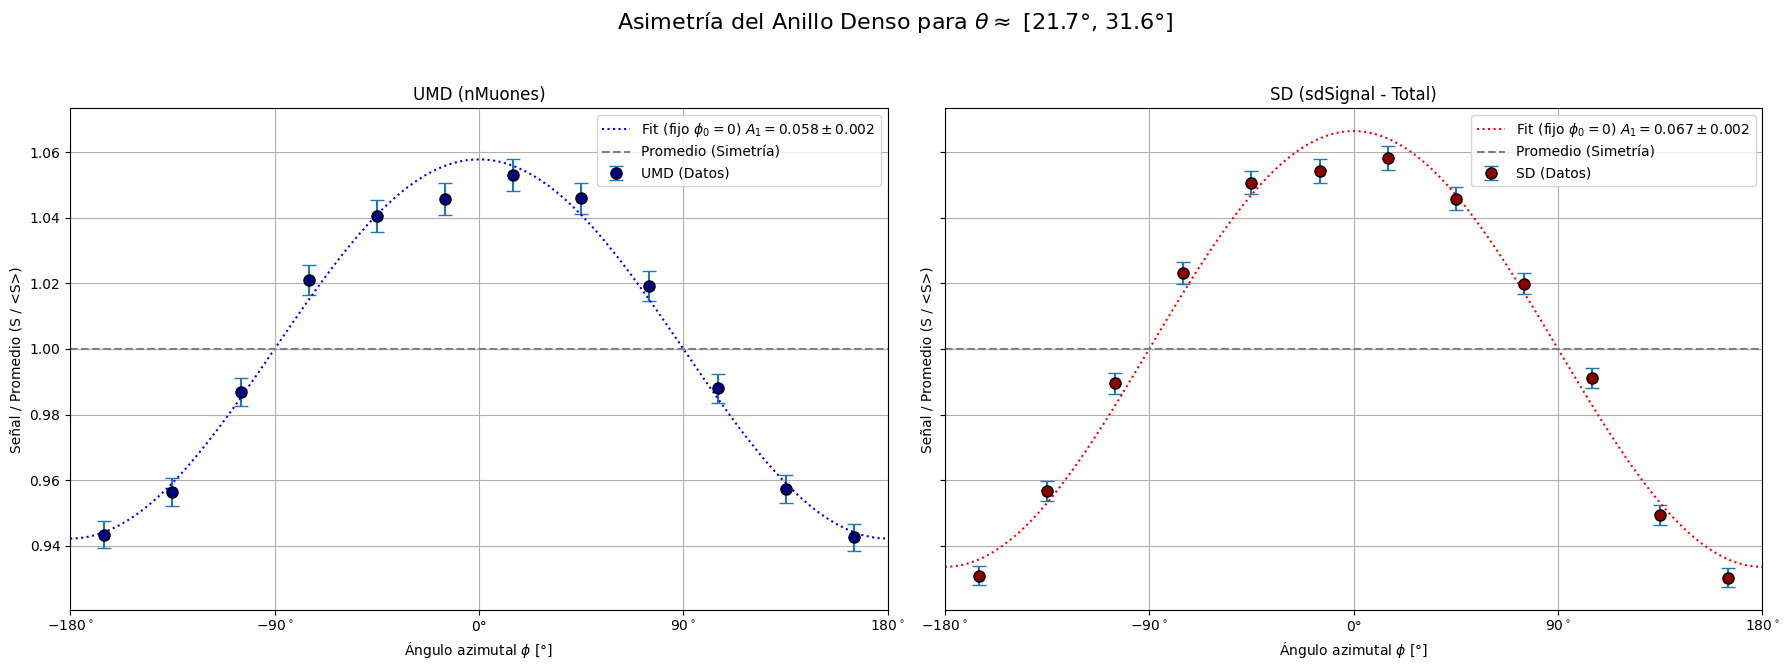

  Procesando bin de theta 2 ([31.6°, 39.9°]): 147888 módulos encontrados.


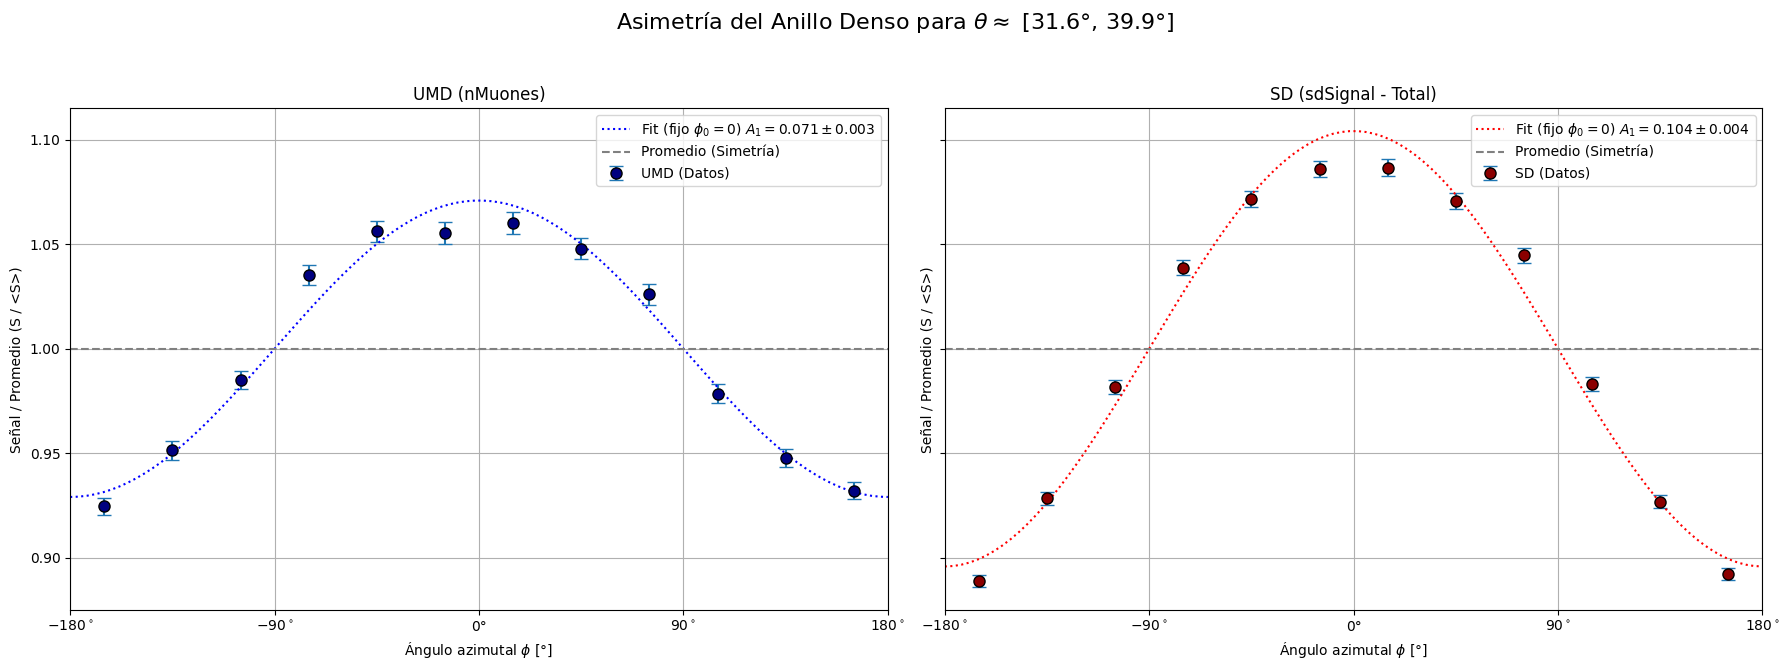

  Procesando bin de theta 3 ([39.9°, 47.7°]): 147768 módulos encontrados.


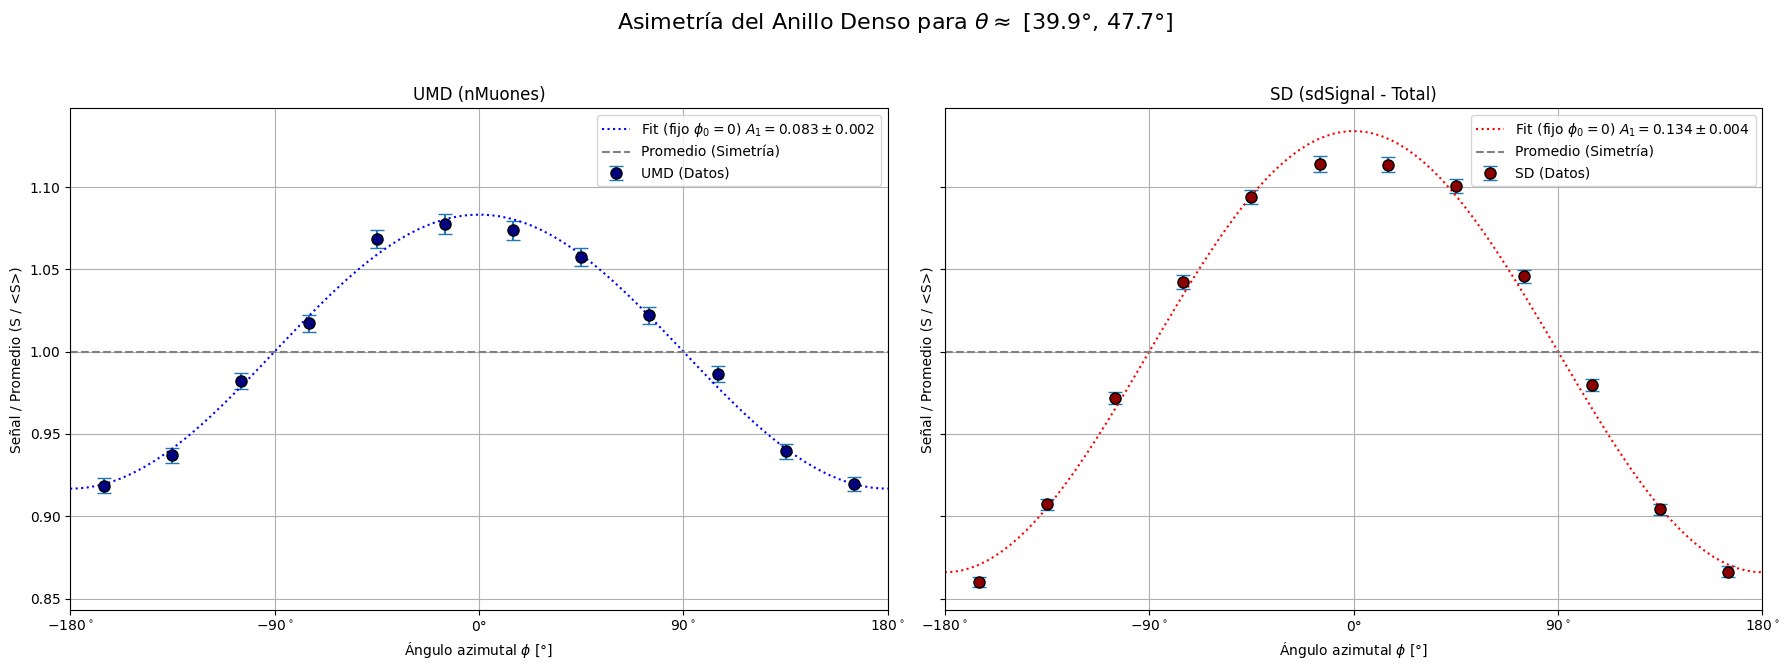

  Procesando bin de theta 4 ([47.7°, 55.8°]): 143457 módulos encontrados.


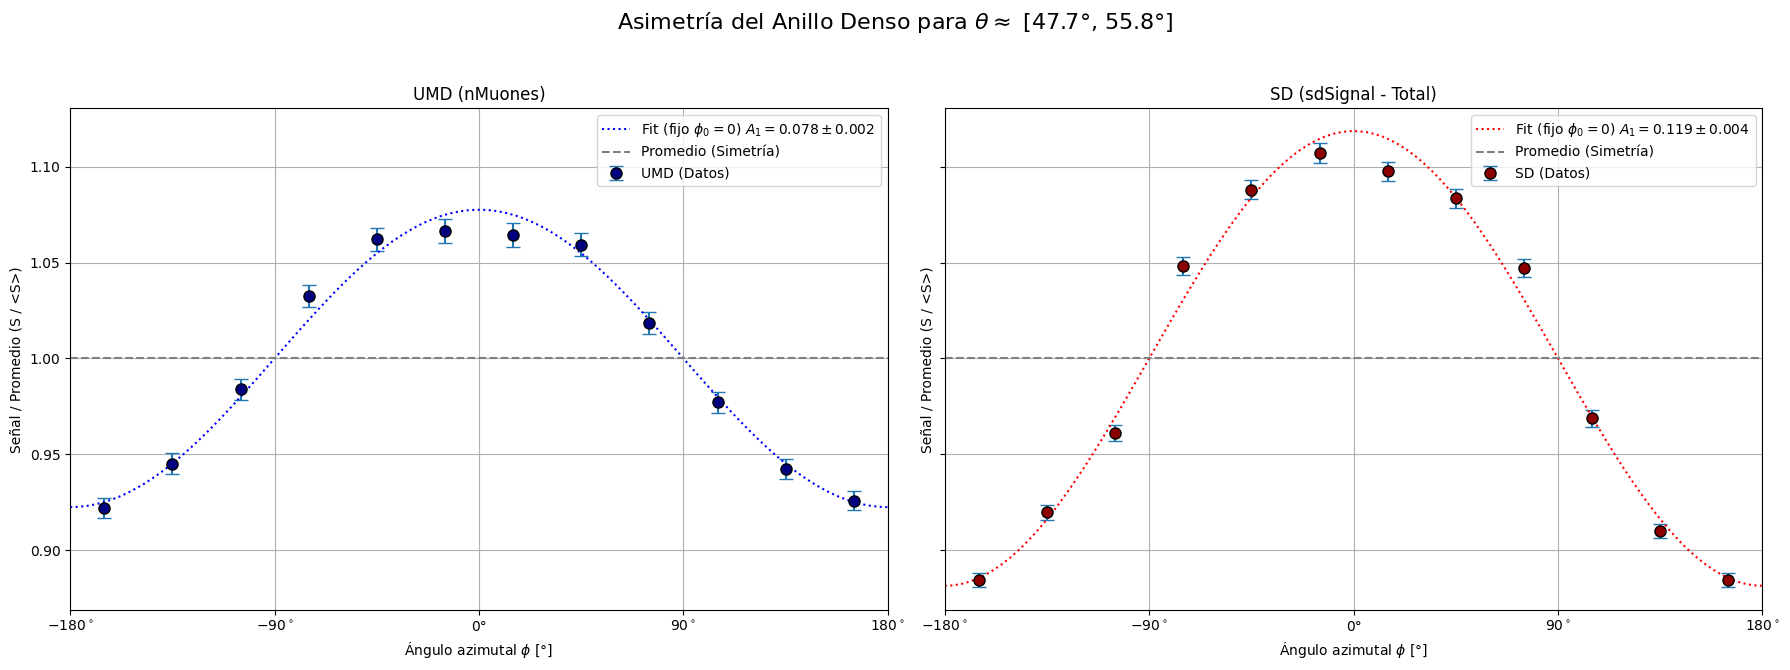

  Procesando bin de theta 5 ([55.8°, 65.0°]): 87480 módulos encontrados.


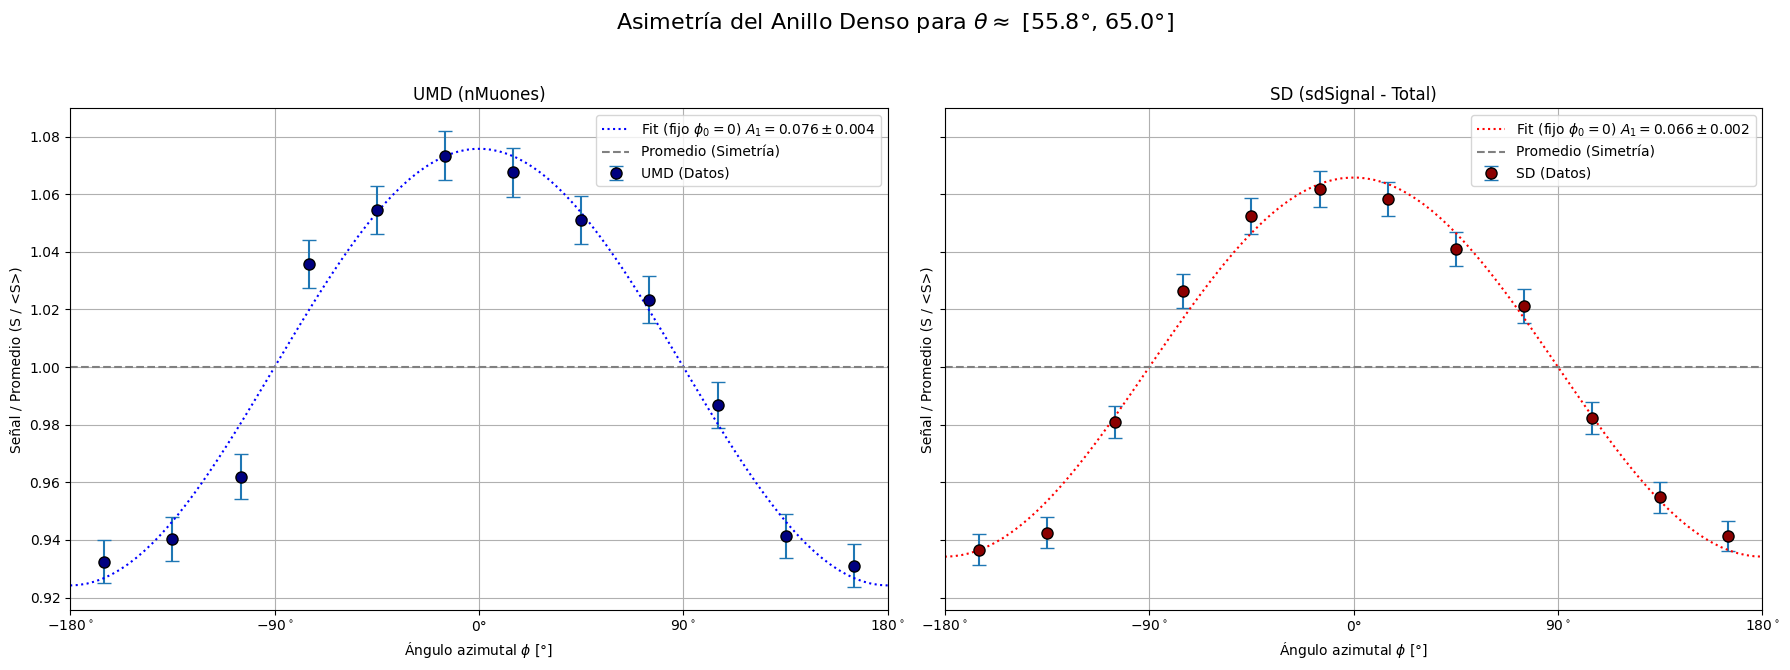


  Resumen Estadístico de Amplitudes de Asimetría (A1)
 theta_bin    theta_range detector     A1  A1_err  phi0_deg  N_modulos
         0  [0.0°, 21.7°]      UMD 0.0281  0.0014    0.0000     157032
         0  [0.0°, 21.7°]       SD 0.0277  0.0015    0.0000     157032
         1 [21.7°, 31.6°]      UMD 0.0579  0.0017    0.0000     149541
         1 [21.7°, 31.6°]       SD 0.0665  0.0024    0.0000     149541
         2 [31.6°, 39.9°]      UMD 0.0709  0.0031    0.0000     147888
         2 [31.6°, 39.9°]       SD 0.1042  0.0041    0.0000     147888
         3 [39.9°, 47.7°]      UMD 0.0832  0.0019    0.0000     147768
         3 [39.9°, 47.7°]       SD 0.1340  0.0038    0.0000     147768
         4 [47.7°, 55.8°]      UMD 0.0775  0.0024    0.0000     143457
         4 [47.7°, 55.8°]       SD 0.1186  0.0036    0.0000     143457
         5 [55.8°, 65.0°]      UMD 0.0758  0.0035    0.0000      87480
         5 [55.8°, 65.0°]       SD 0.0658  0.0023    0.0000      87480


In [7]:
# --- 1. FUNCIÓN DE FIT (CORREGIDA: A0=1, phi0=0 fijos) ---
def fit_func_deg(phi_deg, A1):
    """
    Ajuste de asimetría con fase fija en 0 grados y normalización fija en 1.
    Solo A1 (amplitud) es libre.
    """
    phi0_deg = 0.0 
    return 1.0 * (1 + A1 * np.cos(np.deg2rad(phi_deg - phi0_deg)))

# --- 2. Parámetros de binning ---
phi_plot_bins = 12
phi_bin_edges = np.linspace(-180, 180, phi_plot_bins + 1)
phi_bin_labels = range(phi_plot_bins)
phi_bin_centers = (phi_bin_edges[:-1] + phi_bin_edges[1:]) / 2.0

# --- 3. Binning en Theta ---
N_theta_bins = 6
theta_min_deg = 0
theta_max_deg = 65

theta_max_real = df_new['theta_REC'].max()
theta_max_deg = min(theta_max_deg, theta_max_real) 
s2_min = np.sin(np.deg2rad(theta_min_deg))**2
s2_max = np.sin(np.deg2rad(theta_max_deg))**2
s2_bins = np.linspace(s2_min, s2_max, N_theta_bins + 1)
theta_bins_deg = np.rad2deg(np.arcsin(np.sqrt(s2_bins)))
print(f"Bordes de bins en Theta (grados): {np.round(theta_bins_deg, 1)}")

if 's2_theta' not in df_new.columns:
    df_new['s2_theta'] = np.sin(np.deg2rad(df_new['theta_REC']))**2
    df_new['theta_bin'] = pd.cut(df_new['s2_theta'], bins=s2_bins, labels=False, include_lowest=True)

# --- 4. CREAMOS EL DF "LIMPIO" ---
status_buenos = ['candidate', 'rejected', 'saturated']
df_limpio = df_new[
    (df_new['module_status'].isin(status_buenos)) &
    (df_new['is_sd_saturated'] == False) 
].copy()

phi_plane_deg = np.rad2deg(df_limpio['phi_plane'])
df_limpio['phi_plane_centered_deg'] = (phi_plane_deg + 180) % 360 - 180

# --- 5. FILTRAMOS POR ID para el Anillo Denso ---
df_anillo_denso = df_limpio[
    (df_limpio['counterId'] >= 90000) & 
    (df_limpio['counterId'] < 100000)
].copy()
print(f"Usando {len(df_anillo_denso)} filas (módulos) 'limpios' del Anillo Denso")

# --- 6. INICIALIZAMOS LISTA PARA EL RESUMEN ---
fit_results = []
print(f"\nAnalizando asimetría en el Anillo Denso (IDs 90k)...")

# --- 7. Bucle anidado ---
for i in range(N_theta_bins):
    
    th_min_label = theta_bins_deg[i]
    th_max_label = theta_bins_deg[i+1]
    theta_range_str = f"[{th_min_label:.1f}°, {th_max_label:.1f}°]"
    plot_title_prefix = f"Asimetría del Anillo Denso para $\\theta \\approx$ {theta_range_str}"

    df_slice = df_anillo_denso[
        (df_anillo_denso['theta_bin'] == i) &
        (df_anillo_denso['sdSignal'].notna()) &
        (df_anillo_denso['nMuones_REC'].notna())
    ].copy()

    if df_slice.empty or len(df_slice) < 50:
        print(f"  Bin de theta {i} ({theta_range_str}): Datos insuficientes. Saltando.")
        continue
    
    print(f"  Procesando bin de theta {i} ({theta_range_str}): {len(df_slice)} módulos encontrados.")

    # --- CÁLCULO DE DENSIDAD ---
    df_slice['phi_bin'] = pd.cut(df_slice['phi_plane_centered_deg'], bins=phi_bin_edges, labels=phi_bin_labels, include_lowest=True)
    
    phi_stats_cat = df_slice.groupby('phi_bin', observed=True).agg(
        umd_mean_density=('nMuones_REC', 'mean'),
        umd_std_dev=('nMuones_REC', 'std'),
        umd_N_entries=('nMuones_REC', 'count'),
        sd_mean_density=('sdSignal', 'mean'),
        sd_std_dev=('sdSignal', 'std'),
        sd_N_entries=('sdSignal', 'count')
    )
    
    phi_stats_cat['umd_sem'] = phi_stats_cat['umd_std_dev'] / np.sqrt(phi_stats_cat['umd_N_entries'])
    phi_stats_cat['sd_sem'] = phi_stats_cat['sd_std_dev'] / np.sqrt(phi_stats_cat['sd_N_entries'])

    # --- Normalizar (S/<S>) ---
    # Normalizamos antes del fit, asumiendo media=1.0
    umd_overall_mean = phi_stats_cat['umd_mean_density'].mean()
    sd_overall_mean = phi_stats_cat['sd_mean_density'].mean()

    phi_stats_cat['umd_S_norm'] = phi_stats_cat['umd_mean_density'] / umd_overall_mean
    phi_stats_cat['umd_S_norm_err'] = phi_stats_cat['umd_sem'] / umd_overall_mean
    
    phi_stats_cat['sd_S_norm'] = phi_stats_cat['sd_mean_density'] / sd_overall_mean
    phi_stats_cat['sd_S_norm_err'] = phi_stats_cat['sd_sem'] / sd_overall_mean
    
    # --- Corrección del TypeError (Crear DataFrame limpio) ---
    int_index = phi_stats_cat.index.astype(int)
    phi_stats = pd.DataFrame({
        'phi_center': phi_bin_centers[int_index],
        'umd_S_norm': phi_stats_cat['umd_S_norm'],
        'umd_S_norm_err': phi_stats_cat['umd_S_norm_err'],
        'sd_S_norm': phi_stats_cat['sd_S_norm'],
        'sd_S_norm_err': phi_stats_cat['sd_S_norm_err'],
        'N_umd': phi_stats_cat['umd_N_entries'],
        'N_sd': phi_stats_cat['sd_N_entries']
    })

    # --- Plotear (2 subplots) ---
    fig, axs = plt.subplots(1, 2, figsize=(18, 7), sharey=True)
    fig.suptitle(plot_title_prefix, fontsize=16)

    # --- Plot 1: UMD (nMuones) ---
    x_umd = phi_stats['phi_center']
    y_umd = phi_stats['umd_S_norm']
    yerr_umd = phi_stats['umd_S_norm_err']

    axs[0].errorbar(x_umd, y_umd, yerr=yerr_umd, fmt='o', ms=8, mec='black', mfc='navy', capsize=5, label='UMD (Datos)')
    
    # --- FIT UMD (1 parámetro) ---
    try:
        # p0=[0.05] (estimación inicial de A1)
        popt_umd, pcov_umd = curve_fit(fit_func_deg, x_umd, y_umd, p0=[0.05], sigma=yerr_umd)
        
        A1_umd = popt_umd[0]
        A1_err_umd = np.sqrt(pcov_umd[0,0])
        
        phi_smooth_deg = np.linspace(-180, 180, 100)
        # ❗️ Uso de rf"..." para evitar SyntaxWarning
        axs[0].plot(phi_smooth_deg, fit_func_deg(phi_smooth_deg, *popt_umd), 
                    'b:', label=rf'Fit (fijo $\phi_0=0$) $A_1 = {A1_umd:.3f} \pm {A1_err_umd:.3f}$')
        
        fit_results.append({
            'theta_bin': i, 'theta_range': theta_range_str, 'detector': 'UMD',
            'A1': A1_umd, 'A1_err': A1_err_umd, 'phi0_deg': 0.0, 
            'N_modulos': phi_stats['N_umd'].sum()
        })
    except RuntimeError:
        print(f"  Fit de UMD no convergió para el bin {i}.")

    axs[0].set_title('UMD (nMuones)')

    # --- Plot 2: SD (sdSignal) ---
    x_sd = phi_stats['phi_center']
    y_sd = phi_stats['sd_S_norm']
    yerr_sd = phi_stats['sd_S_norm_err']

    axs[1].errorbar(x_sd, y_sd, yerr=yerr_sd, fmt='o', ms=8, mec='black', mfc='darkred', capsize=5, label='SD (Datos)')

    # --- FIT SD (1 parámetro) ---
    try:
        popt_sd, pcov_sd = curve_fit(fit_func_deg, x_sd, y_sd, p0=[0.05], sigma=yerr_sd)
        
        A1_sd = popt_sd[0]
        A1_err_sd = np.sqrt(pcov_sd[0,0])
        
        phi_smooth_deg = np.linspace(-180, 180, 100)
        # ❗️ Uso de rf"..." para evitar SyntaxWarning
        axs[1].plot(phi_smooth_deg, fit_func_deg(phi_smooth_deg, *popt_sd), 
                    'r:', label=rf'Fit (fijo $\phi_0=0$) $A_1 = {A1_sd:.3f} \pm {A1_err_sd:.3f}$')
        
        fit_results.append({
            'theta_bin': i, 'theta_range': theta_range_str, 'detector': 'SD',
            'A1': A1_sd, 'A1_err': A1_err_sd, 'phi0_deg': 0.0,
            'N_modulos': phi_stats['N_sd'].sum()
        })
    except RuntimeError:
        print(f"  Fit de SD no convergió para el bin {i}.")

    axs[1].set_title('SD (sdSignal - Total)')
    
    # --- Styling (aplicado a ambos) ---
    for ax in axs:
        ax.set_xlabel(r"Ángulo azimutal $\phi$ [°]")
        ax.set_ylabel(r"Señal / Promedio (S / <S>)")
        ax.set_xticks(np.linspace(-180, 180, 5), [r'$-180^\circ$', r'$-90^\circ$', '0°', r'$90^\circ$', r'$180^\circ$'])
        ax.set_xlim(-180, 180)
        ax.axhline(1.0, color='gray', linestyle='--', label='Promedio (Simetría)')
        ax.grid(True)
        ax.legend()
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# --- 8. IMPRIMIR RESUMEN ESTADÍSTICO ---
print("\n" + "="*50)
print("  Resumen Estadístico de Amplitudes de Asimetría (A1)")
print("="*50)
if fit_results:
    df_results = pd.DataFrame(fit_results)
    print(df_results.to_string(index=False, float_format="%.4f"))
else:
    print("No se completó ningún fit.")